In [1]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats

from scipy.stats import shapiro, levene

import scikit_posthocs as sp

from scipy.stats import kruskal

c:\Users\marco\Tesi_2025-26-La-Geometria-degli-Embedding-di-un-LLm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2141.74it/s]


In [2]:

# carico i dataset
synonym_df = pd.read_csv("synonym_pairs_final.csv")
antonym_df = pd.read_csv("antonym_pairs_final.csv")
random_df = pd.read_csv("random_pairs_final.csv")


# creo un unico set con tutte le parole presenti nei tre esperimenti

all_words = set()

# sinonimi
all_words.update(synonym_df["word"])
all_words.update(synonym_df["synonym"])

# contrari
all_words.update(antonym_df["word"])
all_words.update(antonym_df["antonym"])

# random
all_words.update(random_df["word"])
all_words.update(random_df["random"])


print("Numero totale parole:", len(all_words))

Numero totale parole: 638


In [ ]:
#calcolo gli embedding una sola volta grazie a all_words, li metto in un dizionario
embeddings = {}

for word in all_words:
    
    embeddings[word] = model.encode(
        word,
        convert_to_tensor=True
    )


print("Embedding creati:", len(embeddings))

Embedding creati: 638


In [19]:
#salvo il dizionario così da non doverli calcolare ogni volta che apro il progetto

import pickle

with open("embeddings.pkl", "wb") as f:
    pickle.dump(embeddings, f)

In [3]:
#codice da eseguire per avere gli embedding

import pickle

with open("embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [6]:
#funzione per la cosine similarity

def add_cosine_similarity(df, col1, col2):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = embeddings[w1]
        emb2 = embeddings[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [7]:
#funzione per sinonimi

syn_df = add_cosine_similarity(
    synonym_df,
    "word",
    "synonym"
)

print(syn_df.head())

       word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.397232
1   ghastly      macabre  synonym           0.251190
2     dodgy        dicey  synonym           0.389690
3  biweekly  fortnightly  synonym           0.378817
4   pouring      gushing  synonym           0.522623


In [8]:
#funzione per contrari
ant_df = add_cosine_similarity(
    antonym_df,
    "word",
    "antonym"
)

print(ant_df.head())

          word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.814616
1  centralized  decentralized  antonym           0.613580
2   reasonable   unreasonable  antonym           0.696652
3       simple        complex  antonym           0.469160
4      legible      illegible  antonym           0.461158


In [9]:
rand_df = add_cosine_similarity(
    random_df,
    "word",
    "random"
)

print(rand_df.head())

          word       random relation  cosine_similarity
0     plodding    bombastic   random           0.242246
1  unpalatable  melancholic   random           0.300340
2     obliging     definite   random           0.234148
3    punishing  recombinant   random           0.151135
4      opposed        ionic   random           0.161461


In [10]:
#salvo i risultati
syn_df.to_csv(
    "results_synonyms_similarity.csv",
    index=False
)

ant_df.to_csv(
    "results_antonyms_similarity.csv",
    index=False
)

rand_df.to_csv(
    "results_random_similarity.csv",
    index=False
)

In [3]:
#per caricare dataset con cosine similarity

syn_df = pd.read_csv("results_synonyms_similarity.csv")
ant_df = pd.read_csv("results_antonyms_similarity.csv")
rand_df = pd.read_csv("results_random_similarity.csv")

In [12]:
#Statistiche descrittive
#sinonimi
print("SINONIMI")
print(syn_df["cosine_similarity"].describe().round(3))


SINONIMI
count    111.000
mean       0.424
std        0.155
min        0.119
25%        0.294
50%        0.405
75%        0.523
max        0.801
Name: cosine_similarity, dtype: float64


In [13]:
#contrari

print("\nCONTRARI")
print(ant_df["cosine_similarity"].describe().round(3))




CONTRARI
count    111.000
mean       0.532
std        0.173
min        0.170
25%        0.404
50%        0.559
75%        0.655
max        0.877
Name: cosine_similarity, dtype: float64


In [14]:
#random

print("\nRANDOM")
print(rand_df["cosine_similarity"].describe().round(3))


RANDOM
count    111.000
mean       0.218
std        0.073
min        0.025
25%        0.174
50%        0.226
75%        0.261
max        0.432
Name: cosine_similarity, dtype: float64


C:\Users\marco\AppData\Local\Temp\ipykernel_14580\2408664629.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


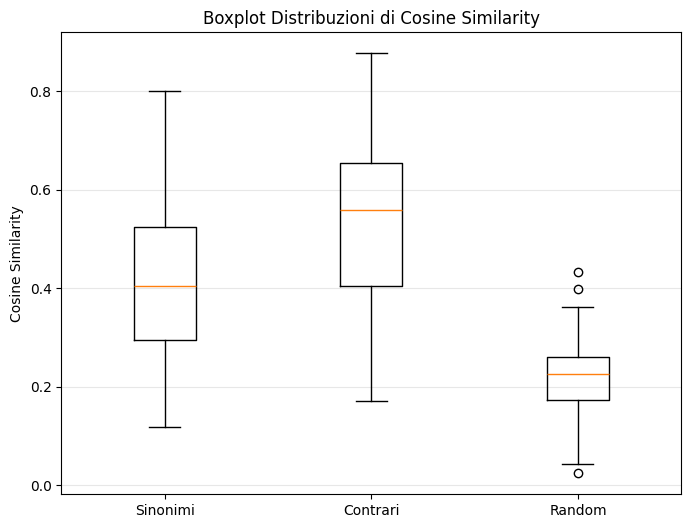

In [26]:
#confronto tra le distribuzioni: box plot
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df["cosine_similarity"],
        ant_df["cosine_similarity"],
        rand_df["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Valutazione se usare Anova o meno 1:
#ci sono evidenze statistiche contro la normalità di distribuzione delle distanze?
#Shapiro-Wilk test

print("Shapiro-Wilk test\n")

for categoria, df in [
    ("Sinonimi", syn_df),
    ("Contrari", ant_df),
    ("Random", rand_df)
]:

    statistic, p_value = shapiro(df["cosine_similarity"])

    print(f"{categoria}")
    print(f"W = {statistic:.4f}")
    print(f"p-value = {p_value:.4f}")

    if p_value > 0.05:
        print("→ La Distribuzione è compatibile con la distribuzione normale.\n")
    else:
        print("→la distribuzione non è compatibile con la distribuzione normale.\n")

Shapiro-Wilk test

Synonyms
W = 0.9783
p-value = 0.0670
→ La Distribuzione è compatibile con la distribuzione normale.

Antonyms
W = 0.9803
p-value = 0.1001
→ La Distribuzione è compatibile con la distribuzione normale.

Random
W = 0.9929
p-value = 0.8413
→ La Distribuzione è compatibile con la distribuzione normale.



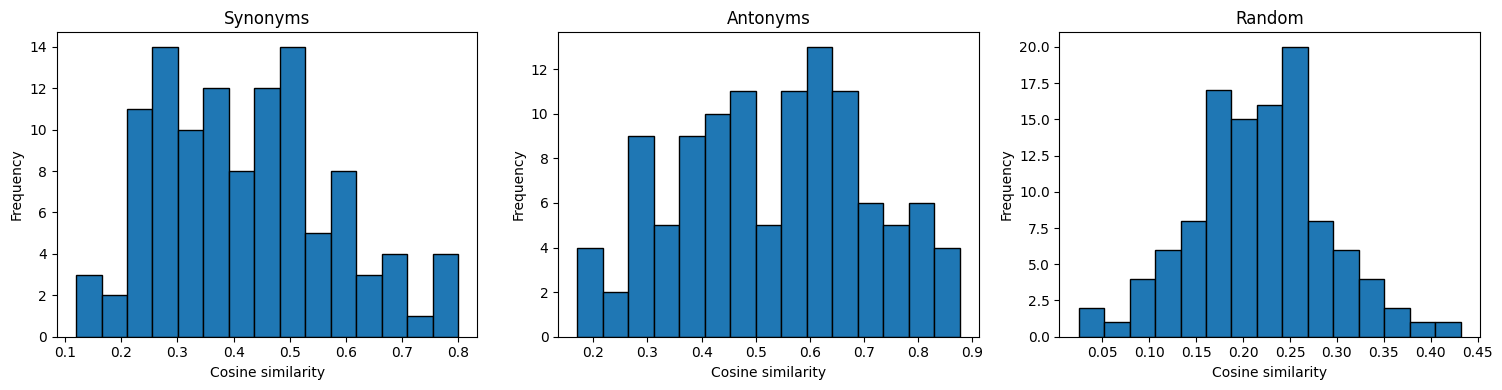

In [21]:
#istogrammi

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    ("Synonyms", syn_df),
    ("Antonyms", ant_df),
    ("Random", rand_df)
]

for ax, (title, df) in zip(axes, datasets):

    ax.hist(
        df["cosine_similarity"],
        bins=15,
        edgecolor="black"
    )

    ax.set_title(title)
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(
    "histograms_cosine_similarity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

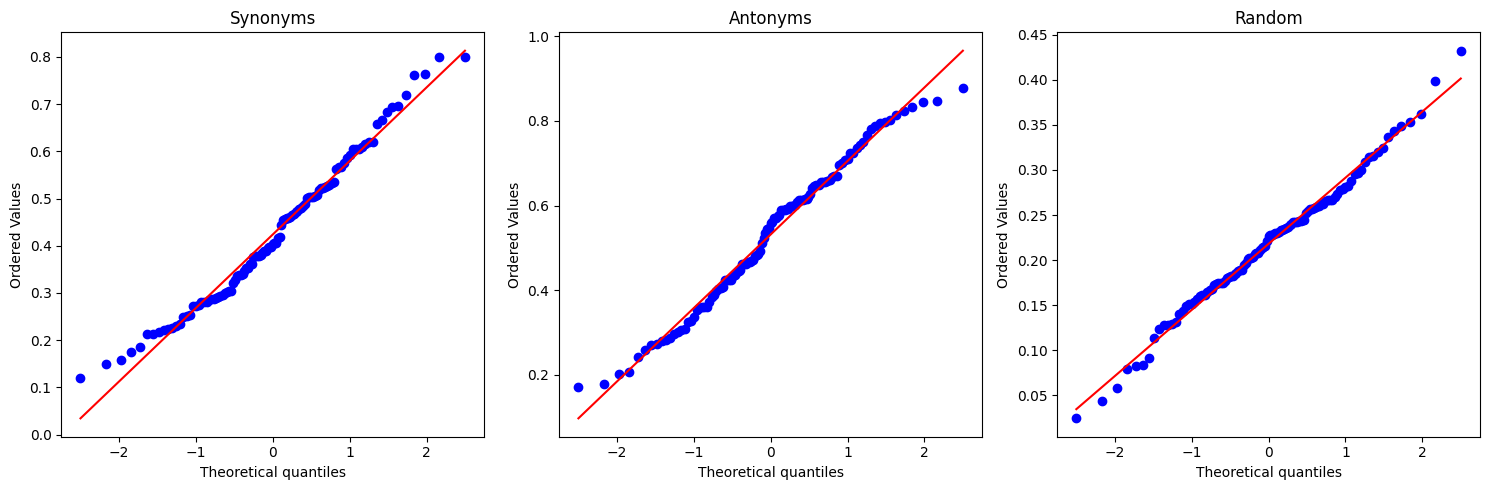

In [25]:
#Q-Q plot

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = [
    ("Synonyms", syn_df),
    ("Antonyms", ant_df),
    ("Random", rand_df)
]

for ax, (title, df) in zip(axes, datasets):

    stats.probplot(df["cosine_similarity"], dist="norm", plot=ax)
    ax.set_title(title)

plt.tight_layout()

plt.savefig(
    "Q-Q_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [24]:
#Test Lavene sull'omogeneità delle varianze tra le 3 distribuzioni (già dal boxplot potevamo ipotizzare che non lo fossero)
F, p_value = stats.levene( syn_df["cosine_similarity"],  ant_df["cosine_similarity"],  rand_df["cosine_similarity"])
print("Levene test\n")
print (f"F = {F.round(4)}")
print(f"\np value = {p_value.round(4)}")
print("\n")
if p_value > 0.05:
    print("→ Le varianze sono omogenee.")
else:
    print("→ Le varianze NON sono omogenee.")

Levene test

F = 37.7722

p value = 0.0


→ Le varianze NON sono omogenee.


In [18]:
#si è scelto di usare un test non parametrico per definire se vi è una significativa differenza di distribuzione delle distanze:
#Test di Kruskall-Wallis
#si aspetta che la random sia significativamente diversa dalle altre due
risultati = stats.kruskal(syn_df["cosine_similarity"], ant_df["cosine_similarity"],  rand_df["cosine_similarity"])
print(risultati)
H = risultati.statistic.round(4)
p_value = risultati.pvalue
epsilon_quadrato = H / (len(syn_df["cosine_similarity"]) + len(ant_df["cosine_similarity"]) + len(rand_df["cosine_similarity"]) - 1)
print(f"H = {H}")
print(f"\np value = {p_value.round(4)}")
print(f"\nEpsilon quadrato = {epsilon_quadrato.round(4)}")
if p_value > 0.05:
    print("Non si riscontra alcuna differenza significativa nelle distribuzione delle distanze dei tre gruppi")
else:
    print("\nAlmeno una distribuzione differisce significativamente dalle altre")


KruskalResult(statistic=np.float64(171.41629864206334), pvalue=np.float64(5.98995687583732e-38))
H = 171.4163

p value = 0.0

Epsilon quadrato = 0.5163

Almeno una distribuzione differisce significativamente dalle altre


In [34]:
#test di Dunn con correzione di Holm per stabilire nello specifico quali distribuzioni differiscono
# Unisco i tre dataset
df_all = pd.concat([
    syn_df.assign(group="Synonyms"),
    ant_df.assign(group="Antonyms"),
    rand_df.assign(group="Random")
])

# Dunn test con correzione di Holm
dunn = sp.posthoc_dunn(
    df_all,
    val_col="cosine_similarity",
    group_col="group",
    p_adjust="holm"
)

#p>=0.5 differenza non significativa
print(dunn.round(4))


          Antonyms  Random  Synonyms
Antonyms    1.0000     0.0    0.0003
Random      0.0000     1.0    0.0000
Synonyms    0.0003     0.0    1.0000


In [33]:
#calcolo il delta per ogni coppia
from cliffs_delta import cliffs_delta

D_antvssyn = cliffs_delta( ant_df["cosine_similarity"], syn_df["cosine_similarity"])
D, res = D_antvssyn
print(f"Contrari vs Sinonimi:{D,res}")

D_antvsrand = cliffs_delta( ant_df["cosine_similarity"], rand_df["cosine_similarity"])
D, res = D_antvsrand
print(f"Contrari vs Random:{D,res}")

D_synvsrand = cliffs_delta( syn_df["cosine_similarity"], rand_df["cosine_similarity"])
D, res = D_synvsrand
print(f"Sinonimi vs Random:{D,res}")


Contrari vs Sinonimi:(0.3562210859508157, 'medium')
Contrari vs Random:(0.9102345588832075, 'large')
Sinonimi vs Random:(0.7815112409707005, 'large')
